In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [5]:
df.shape

(3555, 18)

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,on request,sector 103,1.69,9145.021645,3,3,3+,8.0,Relatively New,1670.0,0,0,0,0,0,0,49
1,house,independent,sector 40,5.00,21123.785382,9,9,3+,3.0,Moderately Old,2367.0,0,1,1,0,0,1,83
2,flat,zara aavaas,sector 104,0.20,6644.518272,1,1,1,3.0,Relatively New,301.0,0,0,0,0,0,0,67
3,house,independent,sector 23,2.80,17983.301220,5,5,3+,2.0,Old Property,1557.0,0,0,0,1,0,1,74
4,house,independent,sector 47,5.15,26614.987080,3,9,3+,3.0,Relatively New,1935.0,0,0,1,0,0,1,75


In [7]:
train_df = df.drop(columns=['society', 'price_per_sqft'])

In [8]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 103,1.69,3,3,3+,8.0,Relatively New,1670.0,0,0,0,0,0,0,49
1,house,sector 40,5.00,9,9,3+,3.0,Moderately Old,2367.0,0,1,1,0,0,1,83
2,flat,sector 104,0.20,1,1,1,3.0,Relatively New,301.0,0,0,0,0,0,0,67
3,house,sector 23,2.80,5,5,3+,2.0,Old Property,1557.0,0,0,0,1,0,1,74
4,house,sector 47,5.15,3,9,3+,3.0,Relatively New,1935.0,0,0,1,0,0,1,75


# luxury score

<Axes: ylabel='luxury_score'>

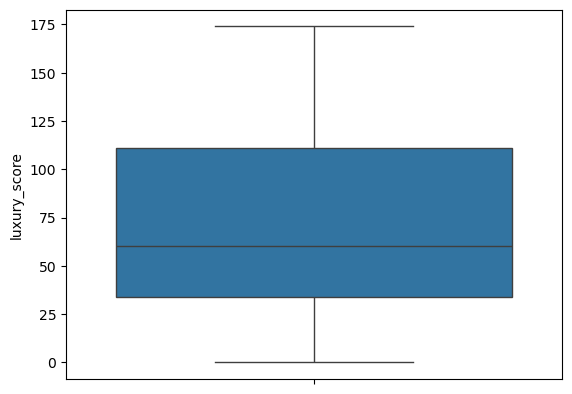

In [9]:
sns.boxplot(df['luxury_score'])

In [12]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return 'Low'
    elif 50 <= score < 150:
        return 'Medium'
    elif 150 <= score <= 175:
        return 'High'
    else:
        return None 

In [13]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [14]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 103,1.69,3,3,3+,8.0,Relatively New,1670.0,0,0,0,0,0,0,49,Low
1,house,sector 40,5.00,9,9,3+,3.0,Moderately Old,2367.0,0,1,1,0,0,1,83,Medium
2,flat,sector 104,0.20,1,1,1,3.0,Relatively New,301.0,0,0,0,0,0,0,67,Medium
3,house,sector 23,2.80,5,5,3+,2.0,Old Property,1557.0,0,0,0,1,0,1,74,Medium
4,house,sector 47,5.15,3,9,3+,3.0,Relatively New,1935.0,0,0,1,0,0,1,75,Medium


# floorNum

<Axes: ylabel='floorNum'>

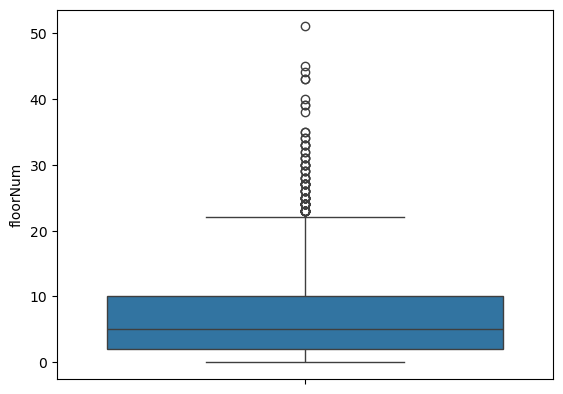

In [15]:
sns.boxplot(df['floorNum'])

In [16]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return 'Low Floor'
    elif 3 <= floor <= 10:
        return 'Mid Floor'
    elif 11 <= floor <= 51:
        return 'High Floor'
    else:
        return None

In [17]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [18]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 103,1.69,3,3,3+,8.0,Relatively New,1670.0,0,0,0,0,0,0,49,Low,Mid Floor
1,house,sector 40,5.00,9,9,3+,3.0,Moderately Old,2367.0,0,1,1,0,0,1,83,Medium,Mid Floor
2,flat,sector 104,0.20,1,1,1,3.0,Relatively New,301.0,0,0,0,0,0,0,67,Medium,Mid Floor
3,house,sector 23,2.80,5,5,3+,2.0,Old Property,1557.0,0,0,0,1,0,1,74,Medium,Low Floor
4,house,sector 47,5.15,3,9,3+,3.0,Relatively New,1935.0,0,0,1,0,0,1,75,Medium,Mid Floor


In [19]:
train_df.drop(columns=['floorNum', 'luxury_score'], inplace= True)

In [20]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 103,1.69,3,3,3+,Relatively New,1670.0,0,0,0,0,0,0,Low,Mid Floor
1,house,sector 40,5.00,9,9,3+,Moderately Old,2367.0,0,1,1,0,0,1,Medium,Mid Floor
2,flat,sector 104,0.20,1,1,1,Relatively New,301.0,0,0,0,0,0,0,Medium,Mid Floor
3,house,sector 23,2.80,5,5,3+,Old Property,1557.0,0,0,0,1,0,1,Medium,Low Floor
4,house,sector 47,5.15,3,9,3+,Relatively New,1935.0,0,0,1,0,0,1,Medium,Mid Floor


In [21]:
from sklearn.preprocessing import OrdinalEncoder

In [23]:
# creating a copy of the original data for label encoding 
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

In [24]:
# apply label encoding to categorical columns 
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [25]:
# splitting the dataset into training and testing sets 
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [26]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,5.0,3,3,4.0,3.0,1670.0,0,0,0,0,0,0,1.0,2.0
1,1.0,48.0,9,9,4.0,0.0,2367.0,0,1,1,0,0,1,2.0,2.0
2,0.0,6.0,1,1,1.0,3.0,301.0,0,0,0,0,0,0,2.0,2.0
3,1.0,28.0,5,5,4.0,2.0,1557.0,0,0,0,1,0,1,2.0,1.0
4,1.0,53.0,3,9,4.0,3.0,1935.0,0,0,1,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,9.0,2,2,2.0,3.0,608.0,0,0,0,0,0,0,1.0,2.0
3551,0.0,96.0,2,2,1.0,3.0,531.0,0,0,1,0,0,0,2.0,2.0
3552,0.0,55.0,3,3,3.0,0.0,2178.0,0,0,0,1,0,0,2.0,2.0
3553,0.0,92.0,3,4,4.0,3.0,1900.0,0,1,0,0,0,2,1.0,0.0


In [27]:
y_label

0       1.69
1       5.00
2       0.20
3       2.80
4       5.15
        ... 
3550    0.36
3551    0.35
3552    1.69
3553    2.20
3554    0.65
Name: price, Length: 3555, dtype: float64

# Technique 1 - Correlation Analysis

<Axes: >

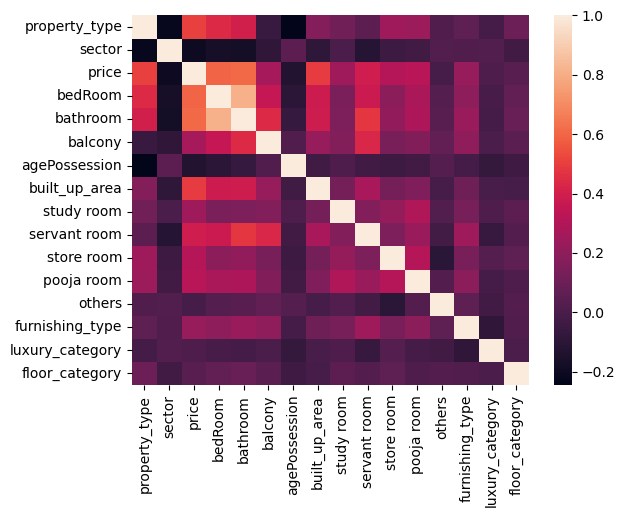

In [28]:
sns.heatmap(data_label_encoded.corr())

In [29]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'feature', 'price':'corr_coeff'})

In [30]:
fi_df1

,feature,corr_coeff
0,sector,-0.203079
1,price,1.000000
2,bedRoom,0.591570
3,bathroom,0.610092
4,balcony,0.269699
5,agePossession,-0.129499
6,built_up_area,0.492796
7,study room,0.241953
8,servant room,0.391878
9,store room,0.305907


# Technique 2 - Random Forest Feature Importance

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
# train a random forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [33]:
# extract feature importance scores for label encoded data 
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending= False)

In [34]:
fi_df2

,feature,rf_importance
6,built_up_area,0.638228
1,sector,0.107791
0,property_type,0.106600
3,bathroom,0.029037
2,bedRoom,0.024613
8,servant room,0.019148
5,agePossession,0.014235
4,balcony,0.012320
12,furnishing_type,0.010419
7,study room,0.009055


# technique 3 - Gradient Boosting Feature Importances 

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

In [36]:
# train a random forest regressor on label encoded data 
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init in

In [37]:
# extract feature importance scores for label encoded data 
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending= False)

In [38]:
fi_df3

,feature,gb_importance
6,built_up_area,6.769373e-01
0,property_type,1.058648e-01
1,sector,1.015949e-01
2,bedRoom,3.445822e-02
3,bathroom,3.399086e-02
8,servant room,2.852115e-02
9,store room,6.055578e-03
5,agePossession,5.214834e-03
12,furnishing_type,3.469249e-03
7,study room,1.515596e-03


# Technique 4 - Permutation Importance

In [39]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [40]:
X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

In [41]:
# train a random forest regressor on lable encoded data 
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [42]:
# calculate premutation importance 
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

In [43]:
# organize results into a dataframe 
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

In [44]:
fi_df4

,feature,permutation_importance
6,built_up_area,0.660488
0,property_type,0.186883
1,sector,0.122154
8,servant room,0.039862
3,bathroom,0.028926
2,bedRoom,0.014724
9,store room,0.006244
10,pooja room,0.005605
4,balcony,0.004226
5,agePossession,0.002203


# Technique 5 - LASSO

In [45]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

In [46]:
# standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

In [47]:
# train a lasso regression model
# we will usee a relatively small value for alpha ( the regularization strength) for demo purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [48]:
# extract coefficients 
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff':lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

In [49]:
fi_df5

,feature,lasso_coeff
0,property_type,0.755287
6,built_up_area,0.712836
3,bathroom,0.512529
2,bedRoom,0.335547
8,servant room,0.320158
9,store room,0.227797
7,study room,0.200832
12,furnishing_type,0.164114
10,pooja room,0.106695
13,luxury_category,0.076560


# Technique 6 - RFE (Recursive Feature Elimination)

In [50]:
from sklearn.feature_selection import RFE

In [51]:
# initialize the base estimator 
estimator = RandomForestRegressor()

In [52]:
# apply rfe on the label encoded and standardized training data 
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

In [53]:
# get the selected features based on RFE 
selected_features = X_label.columns[selector_label.support_]

In [54]:
# extract the coefficients for the selected features from the undrlying linear regression model
selected_coeffificents = selector_label.estimator_.feature_importances_

In [55]:
# organize the results into a dataframe 
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coeffificents
}).sort_values(by='rfe_score', ascending= False)

In [56]:
fi_df6

,feature,rfe_score
6,built_up_area,0.642734
0,property_type,0.110808
1,sector,0.103124
3,bathroom,0.027028
8,servant room,0.023321
2,bedRoom,0.023245
5,agePossession,0.013572
4,balcony,0.012111
12,furnishing_type,0.009279
7,study room,0.008040


# Technique 7 - Linear Regression Weights

In [58]:
# train a linear regression model on the label encoded and standardized training data 
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0.76,-0.13, 0.34,..., 0.17, 0.09,-0.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.439
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[109.98, 70.97, 67.16,..., 43.88, 37.56, 25.06]"


In [59]:
# extract coefficients 
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeff': lin_reg.coef_
}).sort_values(by='reg_coeff', ascending=False)

In [60]:
fi_df7

,feature,reg_coeff
0,property_type,0.761368
6,built_up_area,0.717066
3,bathroom,0.510279
2,bedRoom,0.335163
8,servant room,0.322561
9,store room,0.230356
7,study room,0.206741
12,furnishing_type,0.171853
10,pooja room,0.109788
13,luxury_category,0.086768


# Technique 8 - SHAP

In [73]:
# compute shap values using the trained random forest model 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [75]:
import sys
import socketserver

if sys.platform == "win32":
    if not hasattr(socketserver, "UnixStreamServer"):

        class DummyUnixStreamServer:
            pass

        socketserver.UnixStreamServer = DummyUnixStreamServer

In [78]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

In [79]:
# summing the absolute SHAP values across all samples to get an overall measure of feature importance 
shap_sum = np.abs(shap_values).mean(axis=0)

In [80]:
shap_values

array([[-2.95636803e-01, -1.95134504e-01, -2.44398674e-02, ...,
        -4.72124514e-03,  1.57708779e-02, -1.79177838e-02],
       [ 1.62993856e+00,  2.79205261e-01, -3.09755280e-02, ...,
         2.87690065e-02, -1.36609585e-03,  2.88198172e-03],
       [-1.86985800e-01, -1.53834143e-01, -3.68402285e-02, ...,
        -1.04839714e-02,  5.10477322e-03, -1.40349856e-02],
       ...,
       [-4.73334051e-01,  2.04445058e-01, -2.35698000e-02, ...,
        -3.43922437e-02, -2.56573478e-02, -2.52118474e-02],
       [-3.31490844e-01, -1.34570918e-01, -2.43650659e-02, ...,
         2.19999632e-01, -1.27289935e-02,  2.40887364e-02],
       [-1.81088320e-01, -1.74969486e-01, -5.96922487e-02, ...,
        -1.65530880e-02,  9.96739733e-03, -2.60549564e-02]])

In [81]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis = 0)
}).sort_values(by='SHAP_score', ascending= False)

In [82]:
fi_df8

,feature,SHAP_score
6,built_up_area,1.233801
0,property_type,0.477789
1,sector,0.389450
3,bathroom,0.156765
8,servant room,0.088786
2,bedRoom,0.055307
4,balcony,0.036237
12,furnishing_type,0.027743
5,agePossession,0.024384
14,floor_category,0.023149


In [83]:
final_fi_df = fi_df1.merge(fi_df2, on='feature').merge(fi_df3, on='feature').merge(fi_df4, on='feature').merge(fi_df5, on='feature').merge(fi_df6, on='feature').merge(fi_df7, on='feature').merge(fi_df8, on='feature').set_index('feature')

In [84]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeff,SHAP_score
feature,,,,,,,,
sector,-0.203079,0.107791,1.015949e-01,0.122154,-0.118685,0.103124,-0.126391,0.389450
bedRoom,0.591570,0.024613,3.445822e-02,0.014724,0.335547,0.023245,0.335163,0.055307
bathroom,0.610092,0.029037,3.399086e-02,0.028926,0.512529,0.027028,0.510279,0.156765
balcony,0.269699,0.012320,1.356702e-03,0.004226,0.020923,0.012111,0.027677,0.036237
agePossession,-0.129499,0.014235,5.214834e-03,0.002203,-0.039788,0.013572,-0.047077,0.024384
built_up_area,0.492796,0.638228,6.769373e-01,0.660488,0.712836,0.642734,0.717066,1.233801
study room,0.241953,0.009055,1.515596e-03,0.001695,0.200832,0.008040,0.206741,0.020359
servant room,0.391878,0.019148,2.852115e-02,0.039862,0.320158,0.023321,0.322561,0.088786
store room,0.305907,0.007142,6.055578e-03,0.006244,0.227797,0.005017,0.230356,0.012961


In [85]:
# normalize the score 
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [86]:
final_fi_df[
    [
        "rf_importance",
        "gb_importance",
        "permutation_importance",
        "rfe_score",
        "SHAP_score",
    ]
].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.706575
sector             0.134890
bathroom           0.041671
servant room       0.033430
bedRoom            0.027056
agePossession      0.010225
balcony            0.010192
store room         0.006736
study room         0.006496
furnishing_type    0.006409
luxury_category    0.005054
pooja room         0.004853
floor_category     0.004490
others             0.001922
dtype: float64

In [87]:
# to drop pooka room, study room, other 
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,5.0,3,3,4.0,3.0,1670.0,0,0,0,0,0,0,1.0,2.0
1,1.0,48.0,9,9,4.0,0.0,2367.0,0,1,1,0,0,1,2.0,2.0
2,0.0,6.0,1,1,1.0,3.0,301.0,0,0,0,0,0,0,2.0,2.0
3,1.0,28.0,5,5,4.0,2.0,1557.0,0,0,0,1,0,1,2.0,1.0
4,1.0,53.0,3,9,4.0,3.0,1935.0,0,0,1,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,9.0,2,2,2.0,3.0,608.0,0,0,0,0,0,0,1.0,2.0
3551,0.0,96.0,2,2,1.0,3.0,531.0,0,0,1,0,0,0,2.0,2.0
3552,0.0,55.0,3,3,3.0,0.0,2178.0,0,0,0,1,0,0,2.0,2.0
3553,0.0,92.0,3,4,4.0,3.0,1900.0,0,1,0,0,0,2,1.0,0.0


In [88]:
# with all the cols
from sklearn.model_selection import cross_val_score
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [89]:
scores.mean()

0.8080808942545131

In [90]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(
    rf,
    X_label.drop(columns=["pooja room", "study room", "others"]),
    y_label,
    cv=5,
    scoring="r2",
)

In [91]:
scores.mean()

0.8049644760161051

In [92]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])

export_df['price'] = y_label

In [93]:
export_df.to_csv('gurgaon_properties_post_feature_Selection.csv', index= False)

In [94]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,5.0,3,3,4.0,3.0,1670.0,0,0,0,1.0,2.0,1.69
1,1.0,48.0,9,9,4.0,0.0,2367.0,1,1,1,2.0,2.0,5.00
2,0.0,6.0,1,1,1.0,3.0,301.0,0,0,0,2.0,2.0,0.20
3,1.0,28.0,5,5,4.0,2.0,1557.0,0,0,1,2.0,1.0,2.80
4,1.0,53.0,3,9,4.0,3.0,1935.0,0,1,1,2.0,2.0,5.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,9.0,2,2,2.0,3.0,608.0,0,0,0,1.0,2.0,0.36
3551,0.0,96.0,2,2,1.0,3.0,531.0,0,1,0,2.0,2.0,0.35
3552,0.0,55.0,3,3,3.0,0.0,2178.0,0,0,0,2.0,2.0,1.69
3553,0.0,92.0,3,4,4.0,3.0,1900.0,1,0,2,1.0,0.0,2.20
